In [2]:
# ============================================
# CELL 1: IMPORT LIBRARIES
# ============================================

# Data Handling
import pandas as pd
import numpy as np

# Text Processing
import re
import string

# NLP
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Model Selection & Evaluation
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import PassiveAggressiveClassifier

# Ensemble Learning
from sklearn.ensemble import StackingClassifier

# Model Saving
import joblib

# Suppress Warnings
import warnings
warnings.filterwarnings('ignore')

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [3]:
# ============================================
# CELL 2: LOAD DATASET & BASIC INSPECTION
# ============================================

import kagglehub

# Download latest version of WELFake dataset
path = kagglehub.dataset_download("nitaisatapathy/welfake-dataset")
print(f" Dataset downloaded at: {path}")

# Load the CSV file
df = pd.read_csv(f"{path}/WELFake_Dataset.csv")

# 1. Inspect Dataset Structure
print("=" * 50)
print("DATASET STRUCTURE")
print("=" * 50)
print(f"Shape (Rows, Columns): {df.shape}")
print(f"\nColumn Names:\n{df.columns.tolist()}")
print(f"\nFirst 5 Rows:")
print(df.head())

100%|██████████| 92.1M/92.1M [00:00<00:00, 156MB/s]

Extracting files...


 Dataset downloaded at: /root/.cache/kagglehub/datasets/nitaisatapathy/welfake-dataset/versions/1
DATASET STRUCTURE
Shape (Rows, Columns): (72134, 4)

Column Names:
['Unnamed: 0', 'title', 'text', 'label']

First 5 Rows:
   Unnamed: 0                                              title  \
0           0  LAW ENFORCEMENT ON HIGH ALERT Following Threat...   
1           1                                                NaN   
2           2  UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...   
3           3  Bobby Jindal, raised Hindu, uses story of Chri...   
4           4  SATAN 2: Russia unvelis an image of its terrif...   

                                                text  label  
0  No comment is expected from Barack Obama Membe...      1  
1     Did they post their votes for Hillary already?      1  
2   Now, most of the demonstrators gathered last ...      1  
3  A dozen politically active pastors came here f...      0  
4  The RS-28 Sarmat missile, dubbed Satan 2, will...      1 

In [4]:
# 5. Handle Missing Values

print("MISSING VALUES CHECK")
print("=" * 50)
print("Before handling:")
print(df.isnull().sum())

# Fill text columns with empty string (DO NOT touch label column)
df['title'] = df['title'].fillna('')
df['text'] = df['text'].fillna('')

print("\nAfter handling:")
print(df.isnull().sum())

MISSING VALUES CHECK
Before handling:
Unnamed: 0      0
title         558
text           39
label           0
dtype: int64

After handling:
Unnamed: 0    0
title         0
text          0
label         0
dtype: int64


In [5]:
# 7. Merge Title + Text into single column 'content'
print("\n" + "=" * 50)
print("MERGING TITLE & TEXT")
print("=" * 50)
df['content'] = df['title'] + ' ' + df['text']

# Preview the merged column
print("Sample merged content (first 200 characters):")
print(df['content'].iloc[0][:200] + "...")
print(f"\n New column 'content' created")
print(f"Columns after merging: {df.columns.tolist()}")


MERGING TITLE & TEXT
Sample merged content (first 200 characters):
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #F...

 New column 'content' created
Columns after merging: ['Unnamed: 0', 'title', 'text', 'label', 'content']


In [6]:
# ============================================
# CELL 4: CONVERT TEXT TO LOWERCASE
# ============================================

print("=" * 50)
print("TEXT PREPROCESSING: LOWERCASE CONVERSION")
print("=" * 50)

# Sample before lowercase
print("BEFORE lowercase:")
print(df['content'].iloc[0][:200])
print("\n")

# 8. Convert text to lowercase
df['content'] = df['content'].str.lower()

# Sample after lowercase
print("AFTER lowercase:")
print(df['content'].iloc[0][:200])

print("\nText converted to lowercase successfully!")

TEXT PREPROCESSING: LOWERCASE CONVERSION
BEFORE lowercase:
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #F


AFTER lowercase:
law enforcement on high alert following threats against cops and whites on 9-11by #blacklivesmatter and #fyf911 terrorists [video] no comment is expected from barack obama members of the #fyf911 or #f

Text converted to lowercase successfully!


In [7]:
# ============================================
# CELL 5: REMOVE URLs
# ============================================

print("=" * 50)
print("TEXT PREPROCESSING: REMOVE URLs")
print("=" * 50)


# Ensure the 'content' column is of string type before applying regex
df['content'] = df['content'].astype(str)

# 9. Remove URLs (http, https, www, bit.ly etc.)
df['content'] = df['content'].apply(lambda x: re.sub(r'http\S+|www\S+|https\S+', '', x, flags=re.MULTILINE))


# Check if any URLs were actually removed (optional verification)
url_pattern = r'http\S+|www\S+|https\S+'
sample_with_urls = df['content'].str.contains(url_pattern, na=False).sum()
print(f"\nURLs removed successfully!")
print(f"Rows still containing URLs: {sample_with_urls} (should be 0)")

TEXT PREPROCESSING: REMOVE URLs

URLs removed successfully!
Rows still containing URLs: 0 (should be 0)


In [8]:
# ============================================
# CELL 6: REMOVE EXTRA SPACES
# ============================================

print("=" * 50)
print("TEXT PREPROCESSING: REMOVE EXTRA SPACES")
print("=" * 50)

# Sample before space removal
print("BEFORE removing extra spaces:")
print(f"'{df['content'].iloc[0][:150]}'")  # Quotes show spaces clearly
print(f"Character count: {len(df['content'].iloc[0])}")

# 11. Remove extra spaces (multiple spaces, tabs, newlines -> single space)
df['content'] = df['content'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

print("\nAFTER removing extra spaces:")
print(f"'{df['content'].iloc[0][:150]}'")
print(f"Character count: {len(df['content'].iloc[0])}")

print("\nExtra spaces removed successfully!")

TEXT PREPROCESSING: REMOVE EXTRA SPACES
BEFORE removing extra spaces:
'law enforcement on high alert following threats against cops and whites on 9-11by #blacklivesmatter and #fyf911 terrorists [video] no comment is expec'
Character count: 5180

AFTER removing extra spaces:
'law enforcement on high alert following threats against cops and whites on 9-11by #blacklivesmatter and #fyf911 terrorists [video] no comment is expec'
Character count: 5110

Extra spaces removed successfully!


In [9]:
# ============================================
# CELL 7: REMOVE STOPWORDS
# ============================================

print("=" * 50)
print("TEXT PREPROCESSING: REMOVE STOPWORDS")
print("=" * 50)

# Download stopwords (run once)
nltk.download('stopwords', quiet=True)
stop_words = set(stopwords.words('english'))

print(f"Total English stopwords available: {len(stop_words)}")
print(f"Sample stopwords: {list(stop_words)[:15]}")



# 12. Remove stopwords
def remove_stopwords(text):
    words = text.split()
    filtered_words = [word for word in words if word not in stop_words]
    return ' '.join(filtered_words)

# Apply to dataset
print("\n)")
df['content'] = df['content'].apply(remove_stopwords)


print("\nStopwords removed successfully!")

TEXT PREPROCESSING: REMOVE STOPWORDS
Total English stopwords available: 198
Sample stopwords: ['very', 'for', 'just', 'needn', 'until', 'didn', 'your', 'once', "wouldn't", 'haven', 'o', 'out', 'at', 'over', 'shouldn']

)

Stopwords removed successfully!


In [10]:
# ============================================
#CREATE NEW TEXT FEATURES
# ============================================

print("=" * 50)
print("FEATURE ENGINEERING: TEXT FEATURES")
print("=" * 50)

# Note: We'll create features from ORIGINAL text (before cleaning)
# because uppercase ratio and special chars get lost after cleaning

# 1. Text Length (character count)
df['char_count'] = df['content'].apply(len)

# 2. Word Count
df['word_count'] = df['content'].apply(lambda x: len(x.split()))

# 3. Uppercase Count & Ratio (using original uncleaned text from 'title'+'text')
# We need original text - let's create a temporary column with merged original
original_text = df['title'].fillna('') + ' ' + df['text'].fillna('')

def count_uppercase(text):
    return sum(1 for char in text if char.isupper())

def count_special_chars(text):
    return sum(1 for char in text if not char.isalnum() and not char.isspace())

df['uppercase_count'] = original_text.apply(count_uppercase)
df['uppercase_ratio'] = df['uppercase_count'] / df['char_count']

# 4. Special Character Count & Ratio
df['special_char_count'] = original_text.apply(count_special_chars)
df['special_char_ratio'] = df['special_char_count'] / df['char_count']

# Display statistics
print("\nNew features created!")
print("\n" + "=" * 50)
print("FEATURE STATISTICS")
print("=" * 50)
print(df[['char_count', 'word_count', 'uppercase_count', 'uppercase_ratio',
          'special_char_count', 'special_char_ratio']].describe())

# Compare Fake vs Real for these features
print("\n" + "=" * 50)
print("FAKE vs REAL - FEATURE COMPARISON")
print("=" * 50)
print(df.groupby('label')[['char_count', 'word_count', 'uppercase_ratio', 'special_char_ratio']].mean())

FEATURE ENGINEERING: TEXT FEATURES

New features created!

FEATURE STATISTICS
          char_count    word_count  uppercase_count  uppercase_ratio  \
count   72134.000000  72134.000000     72134.000000     72125.000000   
mean     2474.285039    328.977764       130.246444         0.069165   
std      2736.119790    368.350286       133.118687         0.065598   
min         0.000000      0.000000         0.000000         0.000000   
25%      1088.000000    145.000000        65.000000         0.043350   
50%      1851.000000    245.000000       101.000000         0.054305   
75%      3067.000000    405.000000       159.000000         0.071758   
max    143035.000000  20884.000000      5013.000000         1.500000   

       special_char_count  special_char_ratio  
count        72134.000000        7.213400e+04  
mean            91.586506                 inf  
std            119.408418                 NaN  
min              0.000000        0.000000e+00  
25%             35.000000        

In [11]:
# ============================================
# CELL 9: SEPARATE FEATURES (X) AND TARGET (y)
# ============================================

print("=" * 50)
print("DATA SPLITTING: SEPARATE X AND y")
print("=" * 50)

# 14. Separate Features (X) and Target (y)

# Target variable
y = df['label']

# Features: We have TWO types of features now
# Type 1: Cleaned text (for TF-IDF vectorization)
# Type 2: Engineered numerical features (char_count, word_count, etc.)

# For now, store cleaned text separately
X_text = df['content']  # This is the cleaned text column

# Engineered numerical features
numerical_features = ['char_count', 'word_count', 'uppercase_count', 'uppercase_ratio',
                      'special_char_count', 'special_char_ratio']
X_numerical = df[numerical_features]

print(f"\nFeatures and Target separated!")
print(f"\nTarget (y) shape: {y.shape}")
print(f"Target distribution:")
print(y.value_counts())
print(f"\nText Features (X_text) shape: {X_text.shape}")
print(f"Numerical Features (X_numerical) shape: {X_numerical.shape}")

# Verify no NaN in target
print(f"\nNaN values in target: {y.isnull().sum()}")

# Verify text column has no empty strings
empty_texts = (X_text == '').sum()
print(f"Empty text rows: {empty_texts}")

DATA SPLITTING: SEPARATE X AND y

Features and Target separated!

Target (y) shape: (72134,)
Target distribution:
label
1    37106
0    35028
Name: count, dtype: int64

Text Features (X_text) shape: (72134,)
Numerical Features (X_numerical) shape: (72134, 6)

NaN values in target: 0
Empty text rows: 9


In [12]:
# ============================================
# REMOVE EMPTY ROWS
# ============================================

print("=" * 50)
print("REMOVING EMPTY ROWS")
print("=" * 50)

empty_mask = (X_text == '')
print(f"Empty rows found: {empty_mask.sum()}")

if empty_mask.sum() > 0:
    keep_mask = ~empty_mask

    X_text = X_text[keep_mask]
    X_numerical = X_numerical[keep_mask]
    y = y[keep_mask]

    print(f"Removed {empty_mask.sum()} empty rows")
    print(f"\nNew shapes:")
    print(f"X_text: {X_text.shape}")
    print(f"X_numerical: {X_numerical.shape}")
    print(f"y: {y.shape}")
    print(f"\nEmpty rows remaining: {(X_text == '').sum()}")
else:
    print("No empty rows found")

REMOVING EMPTY ROWS
Empty rows found: 9
Removed 9 empty rows

New shapes:
X_text: (72125,)
X_numerical: (72125, 6)
y: (72125,)

Empty rows remaining: 0


In [13]:
# ============================================
# CHECK EMPTY ROWS
# ============================================

empty_count = (X_text == '').sum()
print(f"Empty rows in X_text: {empty_count}")

nan_count = X_text.isnull().sum()
print(f"NaN values in X_text: {nan_count}")

if empty_count > 0:
    print(f"Indices of empty rows: {X_text[X_text == ''].index.tolist()}")
else:
    print("No empty rows found")

Empty rows in X_text: 0
NaN values in X_text: 0
No empty rows found


In [ ]:
# ============================================
# CELL 11: TF-IDF VECTORIZATION
# ============================================

from sklearn.feature_extraction.text import TfidfVectorizer

print("=" * 50)
print("TEXT VECTORIZATION: TF-IDF")
print("=" * 50)

# Initialize TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=12000,      # Top 12000 words by frequency
    ngram_range=(1, 2),     # Unigrams and Bigrams
    min_df=2,               # Word must appear in at least 2 documents
    max_df=0.9,             # Ignore words that appear in >90% documents
    sublinear_tf=True       # 1 + log(tf) - reduces impact of high frequency words
)

print("Parameters:")
print(f"  max_features: 12000")
print(f"  ngram_range: (1, 2)")
print(f"  min_df: 2")
print(f"  max_df: 0.9")
print(f"  sublinear_tf: True")

print("\nApplying TF-IDF on X_text...")
X_tfidf = tfidf.fit_transform(X_text)

print(f"\nTF-IDF Matrix Shape: {X_tfidf.shape}")
print(f"  Rows (documents): {X_tfidf.shape[0]}")
print(f"  Columns (features): {X_tfidf.shape[1]}")

print(f"\nSparsity: {(X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100:.2f}% non-zero")

TEXT VECTORIZATION: TF-IDF
Parameters:
  max_features: 12000
  ngram_range: (1, 2)
  min_df: 2
  max_df: 0.9
  sublinear_tf: True

Applying TF-IDF on X_text...


In [ ]:
# ============================================
# CELL 12: CHECK CLASS IMBALANCE
# ============================================

print("=" * 50)
print("DATA VALIDATION: CLASS IMBALANCE CHECK")
print("=" * 50)

class_counts = y.value_counts()
print(f"Class Distribution:")
print(f"  Real (1): {class_counts[1]} ({class_counts[1]/len(y)*100:.2f}%)")
print(f"  Fake (0): {class_counts[0]} ({class_counts[0]/len(y)*100:.2f}%)")

imbalance_ratio = class_counts[1] / class_counts[0]
print(f"\nImbalance Ratio (Real/Fake): {imbalance_ratio:.3f}")

if imbalance_ratio < 0.5 or imbalance_ratio > 2.0:
    print(f"\nSignificant imbalance detected. Handling required.")
else:
    print(f"\nClasses are balanced. No handling required.")

DATA VALIDATION: CLASS IMBALANCE CHECK
Class Distribution:
  Real (1): 37097 (51.43%)
  Fake (0): 35028 (48.57%)

Imbalance Ratio (Real/Fake): 1.059

Classes are balanced. No handling required.


In [ ]:
# ============================================
# CELL 13: DEFINE CROSS-VALIDATION STRATEGY
# ============================================

from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression

print("=" * 50)
print("MODEL TRAINING: CROSS-VALIDATION STRATEGY")
print("=" * 50)

# Define 5-Fold Stratified Cross-Validation
cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

print(f"Cross-Validation Strategy Defined:")
print(f"  Method: Stratified K-Fold")
print(f"  Number of Folds: 5")
print(f"  Shuffle: True")
print(f"  Random State: 42")
print(f"\nTotal samples: {X_tfidf.shape[0]}")
print(f"Samples per fold: ~{X_tfidf.shape[0] // 5}")

# Optional: Demonstrate CV with a simple model to show fold-wise scores
print("\n" + "=" * 50)
print("DEMONSTRATION: FOLD-WISE ACCURACY (Logistic Regression)")
print("=" * 50)

demo_model = LogisticRegression(max_iter=1000, random_state=42)

fold = 1
fold_scores = []

for train_idx, val_idx in cv_strategy.split(X_tfidf, y):
    X_train_fold = X_tfidf[train_idx]
    X_val_fold = X_tfidf[val_idx]
    y_train_fold = y.iloc[train_idx]
    y_val_fold = y.iloc[val_idx]

    demo_model.fit(X_train_fold, y_train_fold)
    score = demo_model.score(X_val_fold, y_val_fold)
    fold_scores.append(score)
    print(f"Fold {fold} Accuracy: {score:.4f}")
    fold += 1

print(f"\nAverage Accuracy: {sum(fold_scores)/len(fold_scores):.4f}")
print(f"Standard Deviation: {np.std(fold_scores):.4f}")

MODEL TRAINING: CROSS-VALIDATION STRATEGY
Cross-Validation Strategy Defined:
  Method: Stratified K-Fold
  Number of Folds: 5
  Shuffle: True
  Random State: 42

Total samples: 72125
Samples per fold: ~14425

DEMONSTRATION: FOLD-WISE ACCURACY (Logistic Regression)
Fold 1 Accuracy: 0.9708
Fold 2 Accuracy: 0.9660
Fold 3 Accuracy: 0.9678
Fold 4 Accuracy: 0.9712
Fold 5 Accuracy: 0.9689

Average Accuracy: 0.9689
Standard Deviation: 0.0019


In [ ]:
# ============================================
# CELL 14: TRAIN BASE MODELS
# ============================================

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.linear_model import PassiveAggressiveClassifier
from sklearn.model_selection import train_test_split

print("=" * 50)
print("MODEL TRAINING: BASE MODELS")
print("=" * 50)

# First split data into train and test
X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print(f"Train set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Train label distribution:\n{y_train.value_counts()}")
print(f"Test label distribution:\n{y_test.value_counts()}")

# Initialize models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Naive Bayes': MultinomialNB(),
    'SVM': LinearSVC(random_state=42, dual=False, max_iter=2000),
    'Passive Aggressive': PassiveAggressiveClassifier(max_iter=1000, random_state=42)
}

print("\n" + "=" * 50)
print("TRAINING INDIVIDUAL MODELS")
print("=" * 50)

# Train and evaluate each model
results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    results[name] = {
        'model': model,
        'train_accuracy': train_score,
        'test_accuracy': test_score
    }

    print(f"  Train Accuracy: {train_score:.4f}")
    print(f"  Test Accuracy:  {test_score:.4f}")

print("\n" + "=" * 50)
print("SUMMARY: BASE MODELS PERFORMANCE")
print("=" * 50)
for name, res in results.items():
    print(f"{name:20} | Train: {res['train_accuracy']:.4f} | Test: {res['test_accuracy']:.4f}")

MODEL TRAINING: BASE MODELS
Train set size: 57700
Test set size: 14425
Train label distribution:
label
1    29678
0    28022
Name: count, dtype: int64
Test label distribution:
label
1    7419
0    7006
Name: count, dtype: int64

TRAINING INDIVIDUAL MODELS

Training Logistic Regression...
  Train Accuracy: 0.9774
  Test Accuracy:  0.9673

Training Naive Bayes...
  Train Accuracy: 0.8770
  Test Accuracy:  0.8736

Training SVM...
  Train Accuracy: 0.9964
  Test Accuracy:  0.9756

Training Passive Aggressive...
  Train Accuracy: 0.9999
  Test Accuracy:  0.9718

SUMMARY: BASE MODELS PERFORMANCE
Logistic Regression  | Train: 0.9774 | Test: 0.9673
Naive Bayes          | Train: 0.8770 | Test: 0.8736
SVM                  | Train: 0.9964 | Test: 0.9756
Passive Aggressive   | Train: 0.9999 | Test: 0.9718


MODEL EVALUATION


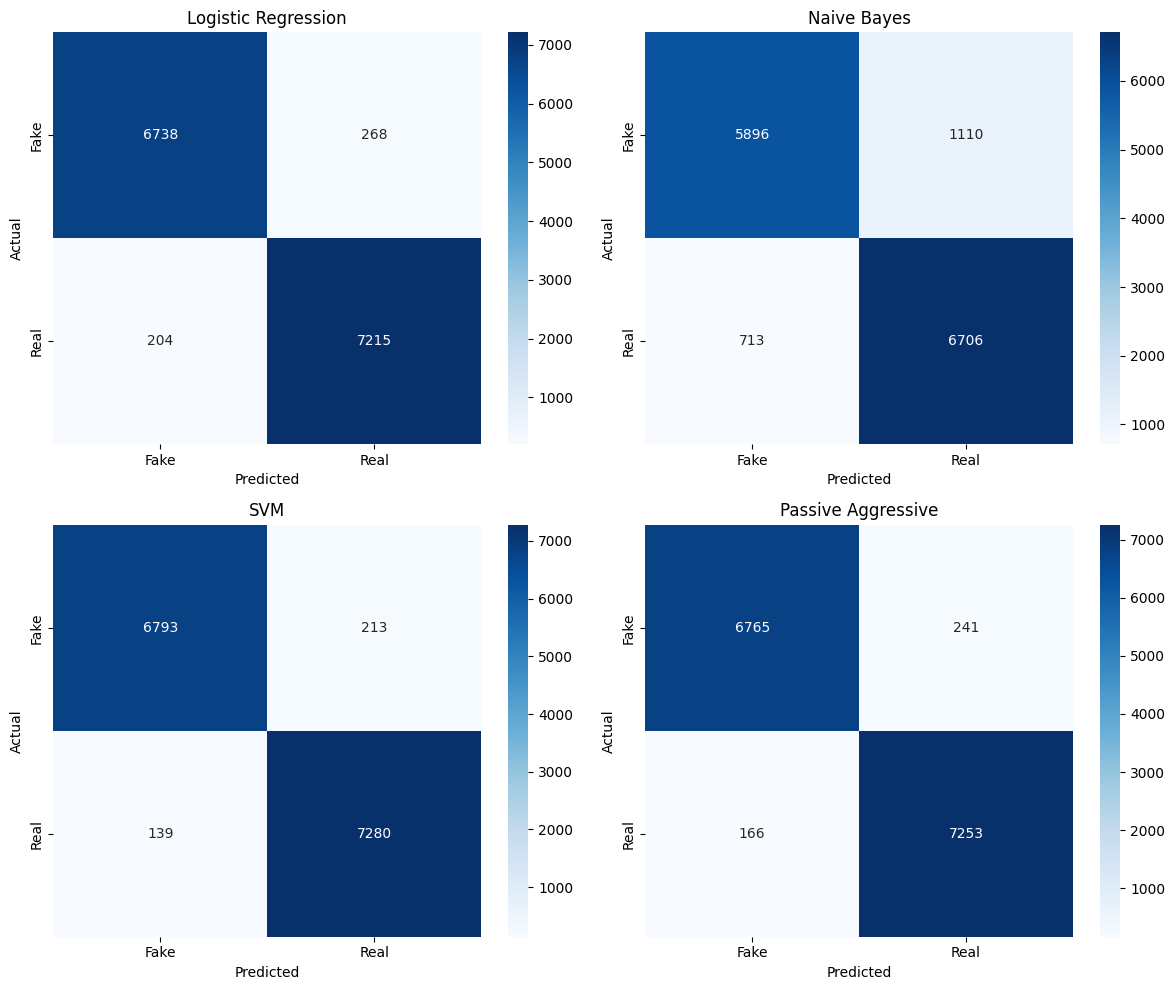

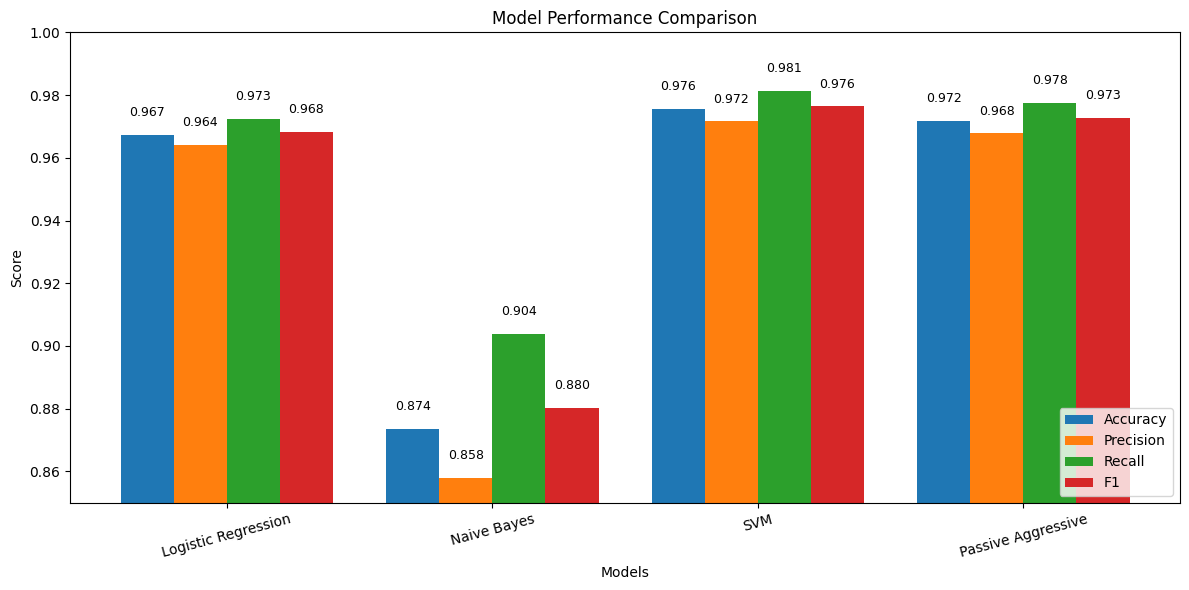

In [ ]:
# ============================================
# CELL 15: DETAILED MODEL EVALUATION
# ============================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 50)
print("MODEL EVALUATION")
print("=" * 50)

for name, res in results.items():
    model = res['model']
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    cm = confusion_matrix(y_test, y_pred)

    results[name]['accuracy'] = acc
    results[name]['precision'] = prec
    results[name]['recall'] = rec
    results[name]['f1'] = f1
    results[name]['confusion_matrix'] = cm
    results[name]['y_pred'] = y_pred

# ============================================
# CONFUSION MATRIX PLOTS
# ============================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for idx, (name, res) in enumerate(results.items()):
    cm = res['confusion_matrix']
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Fake', 'Real'],
                yticklabels=['Fake', 'Real'])
    axes[idx].set_title(f'{name}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ============================================
# COMPARISON BAR CHART
# ============================================
metrics = ['accuracy', 'precision', 'recall', 'f1']
model_names = list(results.keys())

fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(model_names))
width = 0.2

for i, metric in enumerate(metrics):
    values = [results[name][metric] for name in model_names]
    bars = ax.bar(x + i*width, values, width, label=metric.capitalize())
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.005,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Models')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=15)
ax.legend(loc='lower right')
ax.set_ylim(0.85, 1.0)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# CELL 16: BUILD STACKING CLASSIFIER (FAST)
# ============================================

from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

print("=" * 50)
print("ENSEMBLE LEARNING: STACKING CLASSIFIER")
print("=" * 50)

base_models = [
    ('lr', LogisticRegression(max_iter=1000, random_state=42)),
    ('nb', MultinomialNB()),
    ('svm', LinearSVC(random_state=42, dual=False, max_iter=2000)),
    ('pa', PassiveAggressiveClassifier(max_iter=1000, random_state=42))
]

meta_model = LogisticRegression(max_iter=1000, random_state=42)

stacking_model = StackingClassifier(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5
)

print("Base Models:")
for name, _ in base_models:
    print(f"  - {name}")
print(f"Meta Model: Logistic Regression")
print(f"CV Folds: 5")

print("\nTraining Stacking Classifier...")
stacking_model.fit(X_train, y_train)

train_score = stacking_model.score(X_train, y_train)
test_score = stacking_model.score(X_test, y_test)

print(f"\nStacking Model Performance:")
print(f"  Train Accuracy: {train_score:.4f}")
print(f"  Test Accuracy:  {test_score:.4f}")

results['Stacking'] = {
    'model': stacking_model,
    'train_accuracy': train_score,
    'test_accuracy': test_score
}

ENSEMBLE LEARNING: STACKING CLASSIFIER
Base Models:
  - lr
  - nb
  - svm
  - pa
Meta Model: Logistic Regression
CV Folds: 5

Training Stacking Classifier...

Stacking Model Performance:
  Train Accuracy: 0.9960
  Test Accuracy:  0.9753


EVALUATE STACKING MODEL
Stacking Model Metrics:
  Accuracy:  0.9753
  Precision: 0.9732
  Recall:    0.9790
  F1-Score:  0.9761

COMPARISON: ALL MODELS
              Model  Accuracy  Precision   Recall  F1-Score
                SVM  0.975598   0.971573 0.981264  0.976395
           Stacking  0.975321   0.973201 0.978973  0.976078
 Passive Aggressive  0.971785   0.967841 0.977625  0.972708
Logistic Regression  0.967279   0.964185 0.972503  0.968326
        Naive Bayes  0.873622   0.857984 0.903895  0.880341

BEST MODEL
Best Model: SVM (Accuracy: 0.9756)


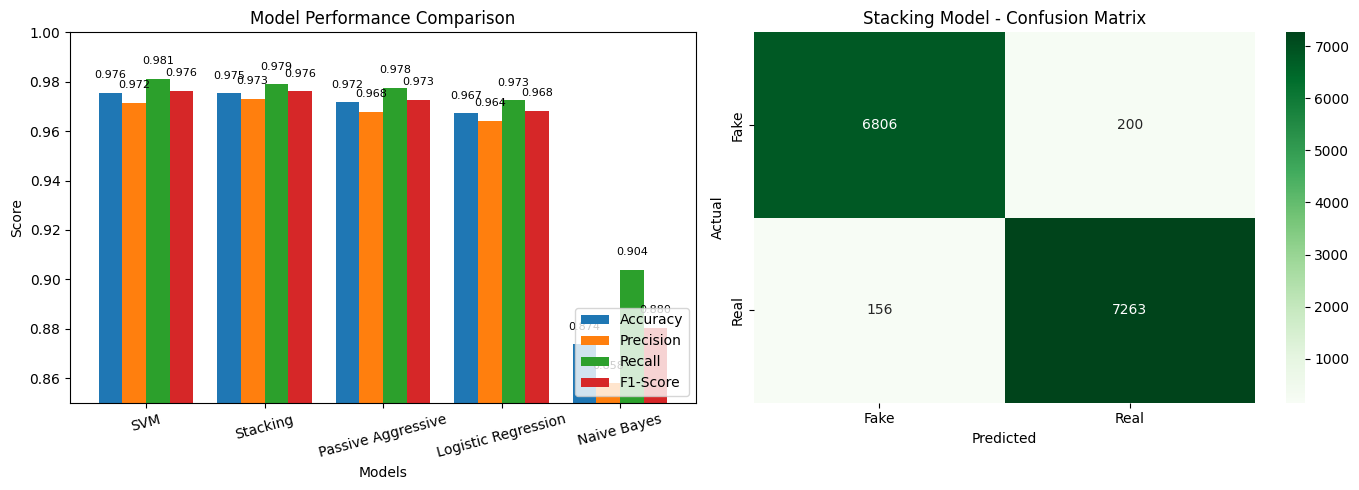

In [ ]:
# ============================================
# CELL 17: EVALUATE STACKING MODEL
# ============================================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 50)
print("EVALUATE STACKING MODEL")
print("=" * 50)

stacking_model = results['Stacking']['model']
y_pred_stacking = stacking_model.predict(X_test)

acc = accuracy_score(y_test, y_pred_stacking)
prec = precision_score(y_test, y_pred_stacking)
rec = recall_score(y_test, y_pred_stacking)
f1 = f1_score(y_test, y_pred_stacking)
cm = confusion_matrix(y_test, y_pred_stacking)

results['Stacking']['accuracy'] = acc
results['Stacking']['precision'] = prec
results['Stacking']['recall'] = rec
results['Stacking']['f1'] = f1
results['Stacking']['confusion_matrix'] = cm

print(f"Stacking Model Metrics:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")

print("\n" + "=" * 50)
print("COMPARISON: ALL MODELS")
print("=" * 50)

comparison_data = []
for name in results.keys():
    comparison_data.append({
        'Model': name,
        'Accuracy': results[name]['accuracy'],
        'Precision': results[name]['precision'],
        'Recall': results[name]['recall'],
        'F1-Score': results[name]['f1']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(comparison_df.to_string(index=False))

print("\n" + "=" * 50)
print("BEST MODEL")
print("=" * 50)
best_model = comparison_df.iloc[0]['Model']
best_accuracy = comparison_df.iloc[0]['Accuracy']
print(f"Best Model: {best_model} (Accuracy: {best_accuracy:.4f})")

# ============================================
# COMPARISON PLOTS
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Bar Chart Comparison
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(comparison_df))
width = 0.2

for i, metric in enumerate(metrics):
    values = comparison_df[metric].values
    bars = axes[0].bar(x + i*width, values, width, label=metric)
    for bar in bars:
        height = bar.get_height()
        axes[0].text(bar.get_x() + bar.get_width()/2., height + 0.005,
                    f'{height:.3f}', ha='center', va='bottom', fontsize=8)

axes[0].set_xlabel('Models')
axes[0].set_ylabel('Score')
axes[0].set_title('Model Performance Comparison')
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(comparison_df['Model'].values, rotation=15)
axes[0].legend(loc='lower right')
axes[0].set_ylim(0.85, 1.0)

# Plot 2: Stacking Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Fake', 'Real'],
            yticklabels=['Fake', 'Real'])
axes[1].set_title(f'Stacking Model - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# SAVE WITH FULL PATH
# ============================================

import joblib
import os

print("=" * 50)
print("SAVING MODEL")
print("=" * 50)

desktop_path = os.path.expanduser("~/Desktop")
model_path = os.path.join(desktop_path, "fake_news_model.pkl")
vectorizer_path = os.path.join(desktop_path, "tfidf_vectorizer.pkl")

try:
    joblib.dump(stacking_model, model_path)
    print(f"Saved: {model_path}")
except Exception as e:
    print(f"Error saving model: {e}")
    model_path = "fake_news_model.pkl"
    joblib.dump(stacking_model, model_path)
    print(f"Saved in current directory: {model_path}")

try:
    joblib.dump(tfidf, vectorizer_path)
    print(f"Saved: {vectorizer_path}")
except:
    vectorizer_path = "tfidf_vectorizer.pkl"
    joblib.dump(tfidf, vectorizer_path)
    print(f"Saved in current directory: {vectorizer_path}")

SAVING MODEL
Error saving model: [Errno 2] No such file or directory: '/root/Desktop/fake_news_model.pkl'
Saved in current directory: fake_news_model.pkl
Saved in current directory: tfidf_vectorizer.pkl


In [ ]:
# ============================================
# DOWNLOAD FILES
# ============================================

from google.colab import files

print("=" * 50)
print("DOWNLOADING FILES")
print("=" * 50)

files.download('fake_news_model.pkl')
print("Downloading model...")

files.download('tfidf_vectorizer.pkl')
print("Downloading vectorizer...")

print("Check your Downloads folder.")

DOWNLOADING FILES


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Check your Downloads folder.
